In [1]:
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from datetime import datetime
import time
from IPython.display import clear_output

import diffrax
import equinox as eqx
import jax
import jax.lax as lax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jr
import numpy as np
import optax  # https://github.com/deepmind/optax
from optax.contrib import reduce_on_plateau as plateau

In [30]:
# MLP
class Func(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, in_size, out_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.mlp = eqx.nn.MLP(
            in_size=in_size,
            out_size=out_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.tanh, 
            # activation=jnn.softplus, 결과가 더 안 좋음
            key=key,
        )

    def __call__(self, t):
        if jnp.shape(t) == ():
            t = jnp.broadcast_to(t, (1,))
        return self.mlp(t)

In [31]:
@dataclass
class SIRConfig:
    beta: float = 0.025
    alpha: float = 0.2
    S0: float = 100.0
    I0: float = 1.0
    t0: float = 0.0
    t1: float = 30.0

    def y0(self):
        return jnp.array([self.S0, self.I0])

    def args(self):
        return (self.beta, self.alpha)

@dataclass
class LossTerms:
    col: jnp.ndarray
    data: jnp.ndarray
    init: jnp.ndarray

    def to_float_tuple(self):
        return float(self.col), float(self.data), float(self.init)

In [32]:
def get_data(dataset_size, config, ts=None, *, key):
    # Initial condition: (S0, I0)
    # y0 = jr.uniform(key, (2,), minval=0, maxval=100)
    y0 = config.y0()
    ts = jnp.linspace(0.1, config.t1, dataset_size) if ts is None else ts

    def f(t, y, args):
        beta, alpha = args
        S, I = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - alpha * I
        return jnp.array([dSdt, dIdt])

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        (diffrax.ODETerm(f)), solver, 0, ts[-1], dt0, y0, args=config.args(), saveat=saveat
    )
    ys = sol.ys
    return ts, ys

In [33]:
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    assert dataset_size >= batch_size
    indices = np.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [34]:
def relative_error(pred, true):
    assert(pred.shape == true.shape)
    
    if pred.ndim == 0:  # Scalar case
        return jnp.abs(pred - true) / jnp.abs(true)
    else:  # Vector (or higher-dimension) case
        return jnp.linalg.norm(pred - true, 2) / jnp.linalg.norm(true, 2)
    
def get_experiment_id():
    return datetime.now().strftime("%Y%m%d%H%M%S%f")


In [ ]:
def main(
    dataset_size=20,
    collocation_size=500,
    batch_size=10, # batch_size == dataset_size
    lr=3e-3,
    steps_strategy=(10000, 10000),
    width_size=64,
    depth=4,
    seed=5678,
    config=SIRConfig(),
    plot=True,
    sampling_strategy = None,
    debug=False # Setting debug = True displays residual, data, and init losses, but slows down training.
):
    batch_size = dataset_size
    test_data_key, data_key, col_key, model_key, loader_key = jr.split(jr.PRNGKey(seed), 5)
    model_key, alpha_key, beta_key = jr.split(model_key, 3)
    ts, ys = get_data(dataset_size, ts=sampling_strategy, config=config, key=data_key)
    cs = jr.uniform(col_key, (collocation_size,), minval=config.t0 + 0.001, maxval=config.t1 - 0.001)

    alpha = jax.random.normal(alpha_key, ())
    beta = jax.random.normal(beta_key, ())
    model = Func(in_size=1, out_size=2, width_size=width_size, depth=depth, key=model_key)
    params = (model, alpha, beta)

    # optim = optax.adam(lr)
    optim = optax.chain(
            optax.adam(lr),
            plateau(patience=1000, accumulation_size=2)
    )  

    @eqx.filter_jit
    def pde_residual(params, x, flag):
        network, alpha, beta = params
        pred = network(x)
        S, I = pred[0], pred[1]

        epsilon = 1e-3
        S = S + epsilon if flag else S
        I = I + epsilon if flag else I

        jac = jax.jacrev(network)(x)
        dSdt, dIdt = jac[0], jac[1]

        res_S = dSdt + beta * S * I
        res_I = dIdt - beta * S * I + alpha * I

        ret = jnp.square(res_S) + jnp.square(res_I)
        return ret
    
    # for debug mode
    def evaluate_loss(params, ti, yi):
        model = params[0]
        
        residual_at_col = jax.vmap(pde_residual, in_axes=(None, 0))(params, cs)
        col_loss = jnp.mean(residual_at_col)
        
        y_pred = jax.vmap(model)(ti)
        data_loss = jnp.mean((y_pred - yi)**2)
        
        y0_pred = model(config.t0)
        init_loss = jnp.mean((y0_pred - config.y0())**2)
        
        losses = LossTerms(col=col_loss, data=data_loss, init=init_loss)
        return losses
    
    @eqx.filter_value_and_grad
    def grad_loss(params, ti, yi, flag):
        model = params[0]
        
        residual_at_col = jax.vmap(pde_residual, in_axes=(None, 0, None))(params, cs, flag)
        col_loss = jnp.mean(residual_at_col)
        
        y_pred = jax.vmap(model)(ti)
        data_loss = jnp.mean((y_pred - yi)**2)
        
        y0_pred = model(config.t0)
        init_loss = jnp.mean((y0_pred - config.y0())**2)
        
        total_loss = col_loss + data_loss + init_loss
        return total_loss

    @eqx.filter_jit
    def make_step(params, ti, yi, opt_state, flag):
        loss, grads = grad_loss(params, ti, yi, flag)
        updates, opt_state = optim.update(grads, opt_state, value=loss)
        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state

    loss_list = []
    col_list, data_list, init_list = [], [], []
    for ind, steps in enumerate(steps_strategy):
        opt_state = optim.init(eqx.filter(params, eqx.is_array))
        for step, (ti, yi) in zip(range(steps), dataloader((ts, ys), batch_size, key=loader_key)):
            start = time.time()
            loss, params, opt_state = make_step(params, ti, yi, opt_state, ind==0)
            loss_list.append(loss)
            
            if debug:
                losses = evaluate_loss(params, ti, yi)
                col, data, init = losses.to_float_tuple()

                col_list.append(col)
                data_list.append(data)
                init_list.append(init)

            end = time.time()
            if step % 100 == 0:
                print(f"step={step}, loss={loss}, Computation time: {end - start}, lr scale: {optax.tree.get(opt_state, 'scale')}")
                clear_output(wait=True)

    if plot:
        exact_ts, exact_ys = get_data(1000, config=config, key=test_data_key)
        model_y = jax.vmap(params[0])(exact_ts)

        # relative error 계산
        rel_S = relative_error(exact_ys[:, 0], model_y[:, 0])
        rel_I = relative_error(exact_ys[:, 1], model_y[:, 1])

        # Figure setup
        figure = plt.figure(figsize=(15,5))
        plt.suptitle(f'Results - PINN')

        # Subplot for Susceptible (S)
        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(exact_ts, exact_ys[:, 0], color='C0', label="Susceptible")
        ax1.plot(exact_ts, model_y[:, 0], linestyle='--', lw=2, color='C2', label='Trained NN')
        ax1.scatter(ts, ys[:, 0], color='red', marker='x', label='Sampled Susceptible', alpha=0.6)
        ax1.set_title(f'S(Relative error: {rel_S:.2e})')
        ax1.set_xlabel('t')
        ax1.legend()

        # Subplot for Infected (I)
        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(exact_ts, exact_ys[:, 1], color='C1', label="Infected")
        ax2.plot(exact_ts, model_y[:, 1], linestyle='--', lw=2, color='C3', label='Trained NN')
        ax2.scatter(ts, ys[:, 1], color='red', marker='x', label='Sampled Infected', alpha=0.6)
        ax2.set_title(f'I(Relative error: {rel_I:.2e})')
        ax2.set_xlabel('t')
        ax2.legend()

        # Subplot for Training Loss
        ax3 = figure.add_subplot(1,3,3)
        ax3.plot(loss_list, label='total_loss')
        if debug:
            ax3.plot(col_list, label='residual_loss')
            ax3.plot(data_list, label='data_loss')
            ax3.plot(init_list, label='init_loss')
        ax3.set_yscale('log')  # y축을 로그 스케일로 변경
        ax3.set_ylim(1e-6, 1e2)  # 적당한 범위로 설정 (필요하면 조정 가능)
        ax3.set_title('loss')
        ax3.set_xlabel('epoch')
        ax3.legend()

        plt.savefig(f"result/pinn_{get_experiment_id()}.png")

    return ts, ys, params

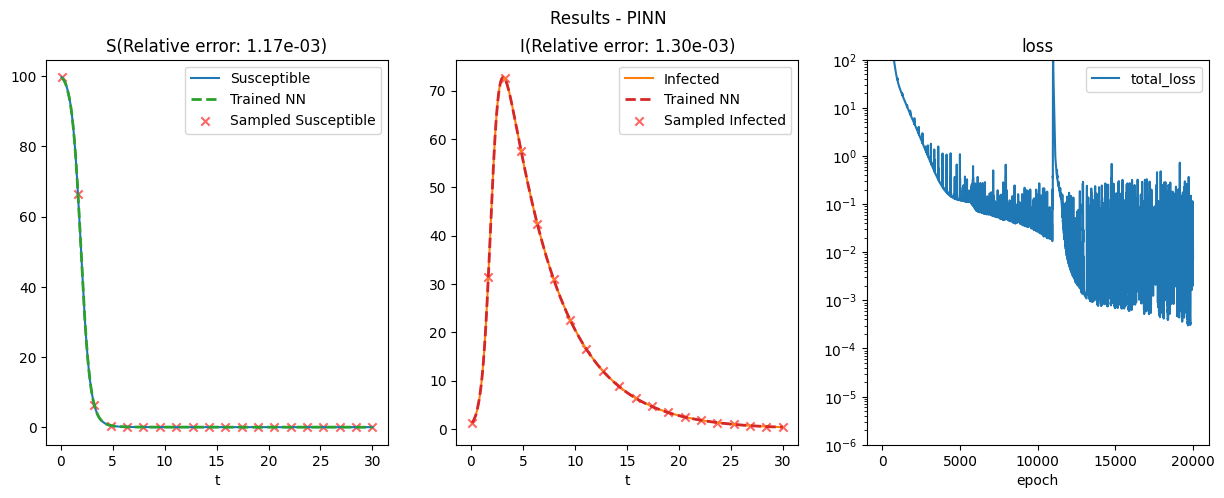

In [44]:
ts, ys, params = main(debug=False)

## Changin the data distribution

In [11]:
# distribution = [
#     jnp.concatenate([jnp.array([0.0]), jnp.linspace(0.1, 3.1, 5)]),
#     jnp.concatenate([jnp.array([0.0]), jnp.linspace(1.8, 6.5, 5)]),
#     jnp.concatenate([jnp.array([0.0]), jnp.linspace(3.1, 10, 5)]),
#     jnp.concatenate([jnp.array([0.0]), jnp.linspace(6.5, 18, 5)]),
# ]

# for dis in distribution:
#     ts, ys, model = main(dataset_size=len(dis), sampling_strategy=dis)

## Changing the number of data points

In [12]:
# for num in [100, 50, 30, 10]:
#     ts, ys, model = main(dataset_size=num)

`eqx.filter_value_and_grad` will calculate the gradient with respect to all floating-point arrays in the first argument (`model`). In this case the `model` parameters will be differentiated, whilst `model.hidden_size` is an integer and will get `None` as its gradient.

Likewise, `eqx.filter_jit` will look at all the arguments passed to `make_step`, and automatically JIT-trace every array and JIT-static everything else. In this case the `model` parameters and the data `x` and `y` will be traced, whilst `model.hidden_size` is an integer and will be static'd instead.